In [1]:
import numpy as np 
import torch, torchvision 
import torch.nn as nn 
import torch.nn.functional as F 
import torchvision.transforms as transforms 
import torch.optim as optim 
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 

In [2]:
torch.manual_seed(20)

In [3]:
if torch.cuda.is_available():
    device = 'cuda'
    print('GPU available')
else:
    device = 'cpu'
    print('only CPU available')

GPU available


In [4]:
learning_rate = 1e-4
batch_train = 64
batch_test = 64

In [5]:
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
train_loader = DataLoader(train_set, batch_size=batch_train, shuffle=True)

In [6]:
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor()) 
test_loader = DataLoader(test_set, batch_size=batch_test, shuffle=True) 

In [7]:
mean = train_set.data.float().mean() 
std = train_set.data.float().std() 

tform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize(mean=[mean / 255.0], std=[std / 255.0])
])
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=tform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=tform) 

In [8]:
train_loader = DataLoader(train_set, batch_size=batch_train, shuffle=True) 
test_loader = DataLoader(test_set, batch_size=batch_test, shuffle=True) 

In [9]:
len(train_loader), len(test_loader) 

(938, 157)

In [10]:
example_data, example_label = next(iter(train_loader)) 

In [11]:
example_data.shape 

torch.Size([64, 1, 28, 28])

In [12]:
example_label.shape 

torch.Size([64])

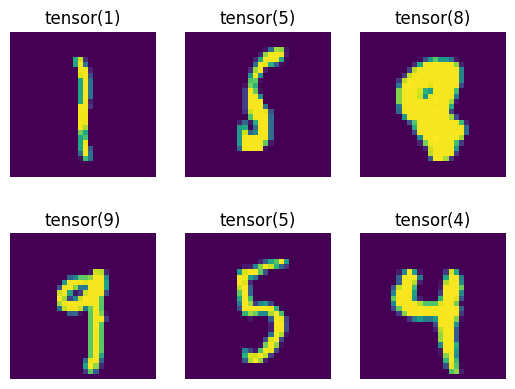

In [13]:
# visualize a few examples 
for i in range(6):
    plt.subplot(2, 3, i+1) 
    plt.imshow(example_data[i].squeeze())
    plt.title(example_label[i]) 
    plt.axis('off')

In [14]:
# define MLP
class MLP(nn.Module):

    def __init__(self, input_dim, hidden_dims, output_dim, bias=True):
        super().__init__() 
        self.mlp = nn.Sequential() 

        in_features = input_dim
        for i in range(len(hidden_dims)):
            out_features = hidden_dims[i] 
            self.mlp.add_module(f'Linear_{i}', nn.Linear(in_features=in_features, out_features=out_features, bias=bias))
            self.mlp.add_module(f'Activation_{i}', nn.ReLU())
            in_features = out_features 
        out_features = output_dim 
        self.mlp.add_module('output_linear', nn.Linear(in_features=in_features, out_features=out_features, bias=bias))
        self.mlp.add_module('output_activation', nn.ReLU())

    def forward(self, x):
        x = self.mlp(x) 
        return x 

In [15]:
model = MLP(input_dim=28*28, hidden_dims=[100, 30, 20], output_dim=10) 
model.to(device)
model 

MLP(
  (mlp): Sequential(
    (Linear_0): Linear(in_features=784, out_features=100, bias=True)
    (Activation_0): ReLU()
    (Linear_1): Linear(in_features=100, out_features=30, bias=True)
    (Activation_1): ReLU()
    (Linear_2): Linear(in_features=30, out_features=20, bias=True)
    (Activation_2): ReLU()
    (output_linear): Linear(in_features=20, out_features=10, bias=True)
    (output_activation): ReLU()
  )
)

In [16]:
# before training, the classification should be wrong 
logits = model(example_data.to(device).view(example_data.shape[0], -1)) 

In [17]:
logits.shape 

torch.Size([64, 10])

In [18]:
print(example_label), print(logits.cpu().detach().argmax(dim=1)) 

tensor([1, 5, 8, 9, 5, 4, 8, 2, 7, 7, 6, 1, 1, 5, 4, 0, 2, 9, 3, 1, 1, 6, 0, 1,
        8, 9, 7, 9, 7, 5, 6, 7, 4, 5, 5, 9, 5, 4, 2, 5, 0, 8, 5, 2, 6, 9, 4, 9,
        9, 7, 3, 8, 2, 0, 3, 7, 6, 7, 1, 0, 8, 0, 7, 0])
tensor([9, 5, 9, 5, 5, 9, 5, 9, 9, 9, 5, 5, 5, 5, 9, 5, 9, 9, 5, 5, 9, 9, 9, 5,
        5, 9, 9, 9, 5, 5, 9, 5, 9, 5, 9, 5, 5, 9, 9, 5, 5, 5, 5, 9, 5, 9, 9, 9,
        9, 9, 9, 5, 9, 5, 5, 9, 5, 9, 9, 9, 9, 5, 9, 9])


(None, None)

In [19]:
train_loss = [] 
test_loss = [] 
train_acc = [] 
test_acc = [] 

In [20]:
n_epochs = 1000 
loss_fn = F.cross_entropy 
optimizer = optim.SGD(params=model.parameters(), lr=learning_rate) 

In [21]:
def train():
    model.train() 

    running_loss = 0 
    running_acc = 0 
    for data, label in train_loader:
        data, label = data.to(device), label.to(device) 
        
        logits = model(data.view(data.shape[0], -1)) 
        loss = loss_fn(logits, label) 
        running_loss += loss.item() 
        acc = (label == logits.argmax(axis=1)).sum()
        running_acc += acc 

        optimizer.zero_grad()
        loss.backward() 
        optimizer.step() 

    train_loss.append(running_loss / len(train_loader)) 
    train_acc.append(running_acc / len(train_set))

In [22]:
def test():
    model.eval() 

    running_loss = 0 
    running_acc = 0 

    with torch.no_grad():
        for data, label in test_loader:
            data, label = data.to(device), label.to(device) 

            logits = model(data.view(data.shape[0], -1)) 
            loss = loss_fn(logits, label)
            running_loss += loss.item() 
            acc = (label == logits.argmax(axis=1)).sum() 
            running_acc += acc 

        test_loss.append(running_loss / len(test_loader))
        test_acc.append(running_acc / len(test_set)) 

In [ ]:
for i in range(n_epochs):
    train() 
    test() 
    if np.mod(i, 10) == 0:
        print(f'epoch {i}, training loss: {train_loss[-1]}, train acc: {train_acc[-1]}, test loss: {test_loss[-1]}, test acc: {test_acc[-1]}')

epoch 0, training loss: 2.3007631833111044, train acc: 0.13643333315849304, test loss: 2.2992196052697054, test acc: 0.141199991106987
epoch 10, training loss: 2.2810971058253795, train acc: 0.15431666374206543, test loss: 2.2782631163384504, test acc: 0.15689998865127563
epoch 20, training loss: 2.2518629346575056, train acc: 0.17444999516010284, test loss: 2.246809257823191, test acc: 0.18539999425411224
epoch 30, training loss: 2.195433904621393, train acc: 0.2805333435535431, test loss: 2.18665239461668, test acc: 0.29979997873306274
epoch 40, training loss: 2.0836251700864925, train acc: 0.46000000834465027, test loss: 2.0670412581437714, test acc: 0.4673999845981598
epoch 50, training loss: 1.8668978197742372, train acc: 0.5192166566848755, test loss: 1.8404484402601886, test acc: 0.5275999903678894
epoch 60, training loss: 1.5997363495420036, train acc: 0.5855333209037781, test loss: 1.5682800188186063, test acc: 0.5916000008583069
epoch 70, training loss: 1.368462721803295, tra

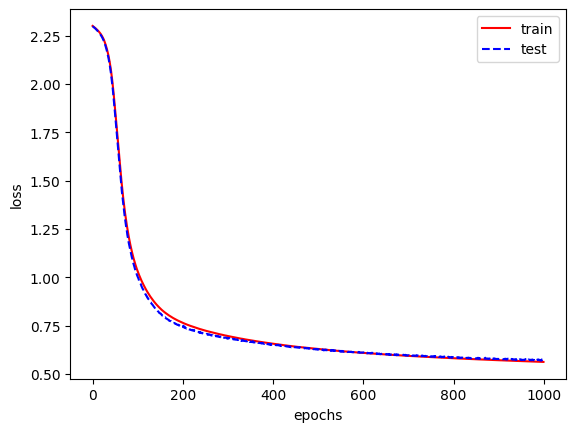

In [27]:
plt.figure()
plt.plot(train_loss, linestyle='-', color='r', label='train')
plt.plot(test_loss, linestyle='--', color='b', label='test')
plt.ylabel('loss')
plt.xlabel('epochs') 
plt.legend()

In [28]:
train_acc = [x.cpu().detach() for x in train_acc]
test_acc = [x.cpu().detach() for x in test_acc] 

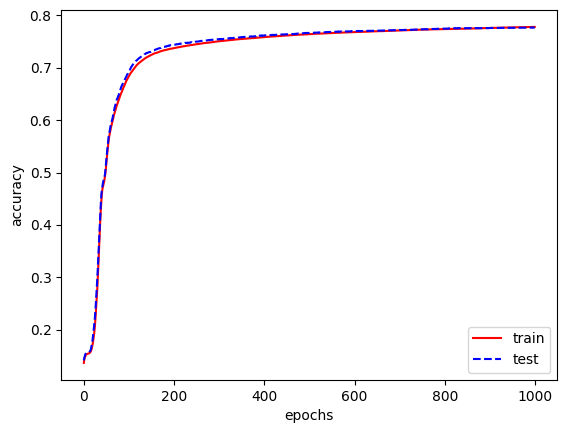

In [29]:
plt.figure()
plt.plot(train_acc, linestyle='-', color='r', label='train')
plt.plot(test_acc, linestyle='--', color='b', label='test')
plt.ylabel('accuracy')
plt.xlabel('epochs') 
plt.legend()